# Drug–Disease Relation Extraction — Evaluation (BERT and BioBERT)

## Task

Binary relation classification on entity-tagged sentences. Given a sentence with a drug and a disease wrapped in special markers (`[DRUG]...[/DRUG]`, `[DISEASE]...[/DISEASE]`), predict whether the drug–disease pair expresses `treats` or `side_effect`. All pairs are assumed related; no `no_relation` class.

## Models

- `bert-base-uncased` — general-English pretrained BERT.
- `dmis-lab/biobert-base-cased-v1.2` — biomedical-pretrained BERT.

Both are fine-tuned for sequence classification with the four entity markers added as special tokens.

## Scope

Reports out-of-distribution evaluation and inference for two trained systems applied to both models:

1. **DrugBank-only baseline** — minimally engineered, single source.
2. **Modified pipeline** — addresses the failure modes the baseline exposes through register alignment, cue-word masking, and clinical-note augmentation.

## Datasets used

There are no publicly available datasets that are suited for the task of drug->disease relation extraction. So we ended up choosing and merging two datasets that had sentences describing the the role and features fo the drug.

1. DrugBank
2. BC5CDR

Both systems are evaluated on AI-generated clinical-note **challenge set** (high difficulty) and **clean clinical test set** (regular difficulty) written once at the end without iteration. In-distribution accuracy is not reported here — it is near-perfect for all four (system, model) combinations and is uninformative about the property of interest, which is generalization to clinical text.

---

## 0. Setup

In [50]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset
from transformers import AutoModelForSequenceClassification, AutoTokenizer

SEEDS = [13, 42, 1234]
MODELS = ["bert", "biobert"]

ROOT = Path(".")
RUNS_DB = ROOT / "runs_db"          
RUNS_V3 = ROOT / "runs_v3"
V3_DIR = ROOT / "merged_v3" 
CHALLENGE = ROOT / "challenge_set.jsonl"
CLIN_TEST = ROOT / "clinical_test.jsonl"

LABEL2ID = {"side_effect": 0, "treats": 1}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def load_jsonl(path):
    path = Path(path)
    if not path.exists():
        return []
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]


def find_checkpoint(run_dir):
    run_dir = Path(run_dir)
    if not run_dir.exists():
        return None
    candidates = sorted(run_dir.glob("checkpoint-*"))
    return candidates[-1] if candidates else None


plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Device: {DEVICE}\n")
for system_name, runs_dir in [("Baseline", RUNS_DB), ("Full pipeline v3", RUNS_V3)]:
    print(f"{system_name} checkpoints:")
    for model in MODELS:
        for s in SEEDS:
            ckpt = find_checkpoint(runs_dir / model / f"seed{s}")
            status = str(ckpt) if ckpt else "(missing)"
            print(f"  {model}/seed{s}: {status}")
    print()

Device: cuda

Baseline checkpoints:
  bert/seed13: runs_db/bert/seed13/checkpoint-390
  bert/seed42: runs_db/bert/seed42/checkpoint-260
  bert/seed1234: runs_db/bert/seed1234/checkpoint-260
  biobert/seed13: runs_db/biobert/seed13/checkpoint-130
  biobert/seed42: runs_db/biobert/seed42/checkpoint-390
  biobert/seed1234: runs_db/biobert/seed1234/checkpoint-130

Full pipeline v3 checkpoints:
  bert/seed13: runs_v3/bert/seed13/checkpoint-422
  bert/seed42: runs_v3/bert/seed42/checkpoint-844
  bert/seed1234: runs_v3/bert/seed1234/checkpoint-844
  biobert/seed13: runs_v3/biobert/seed13/checkpoint-633
  biobert/seed42: runs_v3/biobert/seed42/checkpoint-633
  biobert/seed1234: runs_v3/biobert/seed1234/checkpoint-633



---

## 1. Evaluation function

`eval_checkpoint(ckpt_dir, eval_path)` loads a saved checkpoint and runs it on a JSONL file. Returns accuracy, macro F1, per-class precision/recall/F1, and the confusion matrix. Used for all four (system × model) combinations.

In [55]:
class _EvalDataset(Dataset):
    def __init__(self, rows, tokenizer, max_length=128):
        self.rows = rows
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        enc = self.tokenizer(r["text"], truncation=True,
                             max_length=self.max_length, padding=False)
        return {
            "input_ids": enc["input_ids"],
            "attention_mask": enc["attention_mask"],
            "label": LABEL2ID[r["label"]],
        }


def _collate(batch, pad_id):
    max_len = max(len(b["input_ids"]) for b in batch)
    input_ids = torch.full((len(batch), max_len), pad_id, dtype=torch.long)
    attention_mask = torch.zeros((len(batch), max_len), dtype=torch.long)
    labels = torch.zeros(len(batch), dtype=torch.long)
    for i, b in enumerate(batch):
        L = len(b["input_ids"])
        input_ids[i, :L] = torch.tensor(b["input_ids"])
        attention_mask[i, :L] = torch.tensor(b["attention_mask"])
        labels[i] = b["label"]
    return {"input_ids": input_ids, "attention_mask": attention_mask,
            "labels": labels}


def eval_checkpoint(ckpt_dir, eval_path, batch_size=64, max_length=128):
    """Evaluate a saved HF checkpoint on a JSONL file."""
    from sklearn.metrics import (
        accuracy_score, f1_score, confusion_matrix,
        precision_recall_fscore_support,
    )

    rows = load_jsonl(eval_path)
    if not rows:
        return None

    tokenizer = AutoTokenizer.from_pretrained(str(ckpt_dir))
    model = AutoModelForSequenceClassification.from_pretrained(str(ckpt_dir))
    model.to(DEVICE).eval()

    ds = _EvalDataset(rows, tokenizer, max_length)
    loader = DataLoader(ds, batch_size=batch_size,
                        collate_fn=lambda b: _collate(b, tokenizer.pad_token_id))

    preds, labels = [], []
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            out = model(**batch)
            preds.extend(out.logits.argmax(-1).cpu().numpy().tolist())
            labels.extend(batch["labels"].cpu().numpy().tolist())

    p, r, f, _ = precision_recall_fscore_support(
        labels, preds, labels=[0, 1], zero_division=0
    )
    cm = confusion_matrix(labels, preds, labels=[0, 1])

    return {
        "n": len(labels),
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "side_effect_recall": r[0],
        "treats_recall": r[1],
        "side_effect_f1": f[0],
        "treats_f1": f[1],
        "confusion_matrix": cm.tolist(),
    }


def collect_results(runs_dir, models, eval_sets):
    """Run eval on every (model, seed, eval_set) combination; return long-form DataFrame."""
    rows = []
    for model_name in models:
        for seed in SEEDS:
            ckpt = find_checkpoint(runs_dir / model_name / f"seed{seed}")
            if ckpt is None:
                continue
            for set_name, set_path in eval_sets:
                m = eval_checkpoint(ckpt, set_path)
                if m is None:
                    continue
                rows.append({
                    "model": model_name,
                    "seed": seed,
                    "eval_set": set_name,
                    "accuracy": m["accuracy"],
                    "macro_f1": m["macro_f1"],
                    "side_effect_recall": m["side_effect_recall"],
                    "treats_recall": m["treats_recall"],
                    "confusion_matrix": m["confusion_matrix"],
                    "n": m["n"],
                })
    return pd.DataFrame(rows)


def aggregate(df):
    if df.empty:
        return df
    return df.groupby(["model", "eval_set"]).agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        treats_recall_mean=("treats_recall", "mean"),
        side_effect_recall_mean=("side_effect_recall", "mean"),
        n_seeds=("seed", "count"),
    ).reset_index()

---

## 2. DrugBank-only baseline — clinical OOD evaluation

Trained on DrugBank `indication` (TREATS) and `toxicity` (CAUSES → side_effect) fields with entity masking at p=0.30 per span. No exposure to BC5CDR or to clinical-note text during training.

In [56]:
OOD_EVAL_SETS = [
    ("challenge_set (clinical)", CHALLENGE),
    ("clinical_test (clean held-out)", CLIN_TEST),
]

baseline_df = collect_results(RUNS_DB, MODELS, OOD_EVAL_SETS)
baseline_df

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 10592.87it/s]


,model,seed,eval_set,accuracy,macro_f1,side_effect_recall,treats_recall,confusion_matrix,n
0,bert,13,challenge_set (clinical),0.500000,0.384405,0.933333,0.066667,"[[14, 1], [14, 1]]",30
1,bert,13,clinical_test (clean held-out),0.533333,0.403409,1.000000,0.066667,"[[15, 0], [14, 1]]",30
2,bert,42,challenge_set (clinical),0.500000,0.333333,1.000000,0.000000,"[[15, 0], [15, 0]]",30
3,bert,42,clinical_test (clean held-out),0.500000,0.333333,1.000000,0.000000,"[[15, 0], [15, 0]]",30
4,bert,1234,challenge_set (clinical),0.566667,0.466484,1.000000,0.133333,"[[15, 0], [13, 2]]",30
5,bert,1234,clinical_test (clean held-out),0.566667,0.466484,1.000000,0.133333,"[[15, 0], [13, 2]]",30
6,biobert,13,challenge_set (clinical),0.533333,0.403409,1.000000,0.066667,"[[15, 0], [14, 1]]",30
7,biobert,13,clinical_test (clean held-out),0.500000,0.333333,1.000000,0.000000,"[[15, 0], [15, 0]]",30
8,biobert,42,challenge_set (clinical),0.600000,0.523810,1.000000,0.200000,"[[15, 0], [12, 3]]",30
9,biobert,42,clinical_test (clean held-out),0.533333,0.403409,1.000000,0.066667,"[[15, 0], [14, 1]]",30


In [57]:
baseline_summary = aggregate(baseline_df)
baseline_summary

,model,eval_set,accuracy_mean,accuracy_std,treats_recall_mean,side_effect_recall_mean,n_seeds
0,bert,challenge_set (clinical),0.522222,0.038490,0.066667,0.977778,3
1,bert,clinical_test (clean held-out),0.533333,0.033333,0.066667,1.000000,3
2,biobert,challenge_set (clinical),0.600000,0.066667,0.200000,1.000000,3
3,biobert,clinical_test (clean held-out),0.577778,0.107152,0.155556,1.000000,3


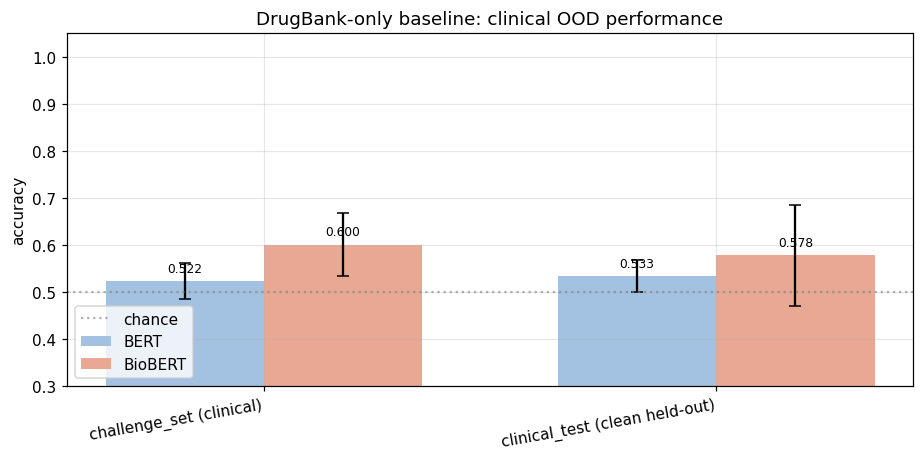

In [58]:
MODEL_COLORS = {"bert": "#3b7dd8", "biobert": "#d8533b"}
MODEL_COLORS_LIGHT = {"bert": "#a3c1e0", "biobert": "#e8a894"}


def plot_acc_by_model(summary, title, ylim=(0.3, 1.05), color_map=None):
    if summary.empty:
        print("no data to plot")
        return
    color_map = color_map or MODEL_COLORS
    eval_order = summary["eval_set"].unique().tolist()
    models_present = summary["model"].unique().tolist()
    x = np.arange(len(eval_order))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8.5, 4.3))
    for i, model in enumerate(models_present):
        rows = summary[summary["model"] == model]
        means = [rows[rows["eval_set"] == e]["accuracy_mean"].values[0]
                 for e in eval_order]
        stds = [rows[rows["eval_set"] == e]["accuracy_std"].fillna(0).values[0]
                for e in eval_order]
        offset = (i - (len(models_present) - 1) / 2) * width
        ax.bar(x + offset, means, width, yerr=stds, capsize=4,
               label=model.upper() if model == "bert" else "BioBERT",
               color=color_map[model])
        for xi, m in zip(x + offset, means):
            ax.text(xi, m + 0.02, f"{m:.3f}", ha="center", fontsize=8)
    ax.axhline(0.5, color="gray", linestyle=":", alpha=0.6, label="chance")
    ax.set_xticks(x)
    ax.set_xticklabels(eval_order, rotation=10, ha="right")
    ax.set_ylabel("accuracy")
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.legend(loc="lower left")
    plt.tight_layout()
    plt.show()


plot_acc_by_model(baseline_summary,
                  "DrugBank-only baseline: clinical OOD performance",
                  color_map=MODEL_COLORS_LIGHT)

### Recall asymmetry (BERT)

Both baseline models show the same qualitative pattern: side_effect recall ~100%, treats recall collapsed. The chart below illustrates it for BERT; BioBERT's asymmetry is similar.

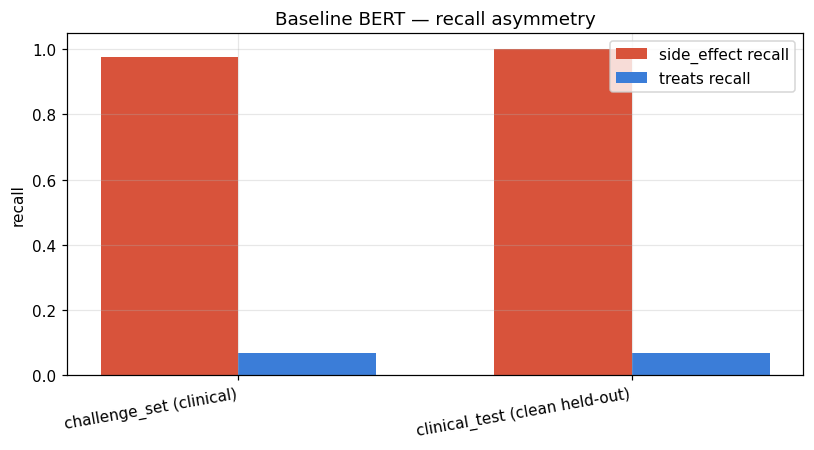

In [59]:
def plot_recall_asymmetry(df, model_name, title):
    sub = df[df["model"] == model_name]
    if sub.empty:
        print("no data")
        return
    grouped = sub.groupby("eval_set").agg(
        side_effect_recall=("side_effect_recall", "mean"),
        treats_recall=("treats_recall", "mean"),
    ).reset_index()
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    eval_order = grouped["eval_set"].tolist()
    x = np.arange(len(eval_order))
    width = 0.35
    ax.bar(x - width/2, grouped["side_effect_recall"], width,
           color="#d8533b", label="side_effect recall")
    ax.bar(x + width/2, grouped["treats_recall"], width,
           color="#3b7dd8", label="treats recall")
    ax.set_xticks(x)
    ax.set_xticklabels(eval_order, rotation=10, ha="right")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("recall")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()


plot_recall_asymmetry(baseline_df, "bert",
                      "Baseline BERT — recall asymmetry")

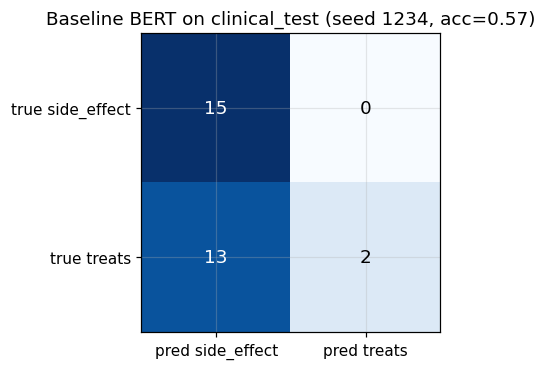

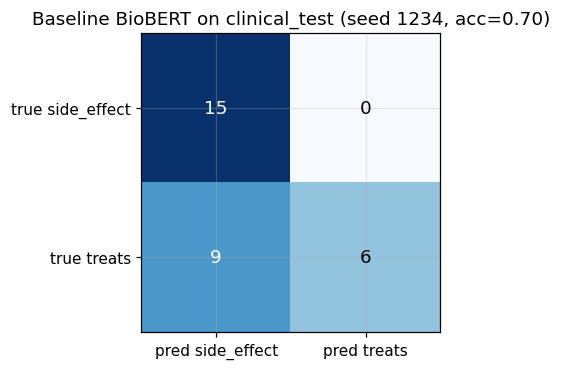

In [60]:
def plot_confusion(cm, title, labels=("side_effect", "treats")):
    cm = np.array(cm)
    fig, ax = plt.subplots(figsize=(4, 3.5))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([f"pred {l}" for l in labels])
    ax.set_yticklabels([f"true {l}" for l in labels])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black",
                    fontsize=12)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# Show the best-seed confusion matrix on clinical_test for each model.
if not baseline_df.empty:
    for model in MODELS:
        sub = baseline_df[(baseline_df["model"] == model) &
                          (baseline_df["eval_set"] == "clinical_test (clean held-out)")]
        if sub.empty:
            continue
        best = sub.loc[sub["accuracy"].idxmax()]
        plot_confusion(
            best["confusion_matrix"],
            f"Baseline {model.upper() if model == 'bert' else 'BioBERT'} on clinical_test "
            f"(seed {best['seed']}, acc={best['accuracy']:.2f})",
        )

## 2.5 The register-shortcut discovery

Ran a simple bag-of-words logistic regression on the merged training data and measured accuracy on dev. The reason: if a linear model with no entity awareness can already solve the task, then the task is not really relation extraction, it's classification on superficial features.

The function below reproduces the probe on any `(train, dev)` pair of JSONL files. It strips entity markers first so the probe measures content leakage rather than marker position.

In [61]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

MARKERS = ("[DRUG]", "[/DRUG]", "[DISEASE]", "[/DISEASE]")

v3_splits = {
    name: load_jsonl(V3_DIR / f"{name}.jsonl")
    for name in ["train", "dev", "test"]
}

def strip_markers(text):
    for m in MARKERS:
        text = text.replace(m, "")
    return " ".join(text.split())


def bow_probe(train_rows, dev_rows, top_k=10):
    if not train_rows or not dev_rows:
        return None

    X_train = [strip_markers(r["text"]) for r in train_rows]
    y_train = [r["label"] for r in train_rows]
    X_dev = [strip_markers(r["text"]) for r in dev_rows]
    y_dev = [r["label"] for r in dev_rows]

    vec = CountVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000)
    Xtr = vec.fit_transform(X_train)
    Xdv = vec.transform(X_dev)

    clf = LogisticRegression(max_iter=1000, C=1.0)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xdv)
    
    pos_class = clf.classes_[1]
    neg_class = clf.classes_[0]
    features = vec.get_feature_names_out()
    top_pos = [f for _, f in sorted(
        zip(clf.coef_[0], features), reverse=True
    )[:top_k]]
    top_neg = [f for _, f in sorted(
        zip(clf.coef_[0], features)
    )[:top_k]]

    return {
        "accuracy": accuracy_score(y_dev, pred),
        "macro_f1": f1_score(y_dev, pred, average="macro"),
        f"top_{pos_class}": top_pos,
        f"top_{neg_class}": top_neg,
    }


probe_v3 = bow_probe(v3_splits["train"], v3_splits["dev"])
if probe_v3:
    print(f"BoW probe on merged_v2/:")
    print(f"  accuracy : {probe_v3['accuracy']:.4f}")
    print(f"  macro F1 : {probe_v3['macro_f1']:.4f}")
    print(f"  top features for 'treats'      : {', '.join(probe_v3['top_treats'])}")
    print(f"  top features for 'side_effect' : {', '.join(probe_v3['top_side_effect'])}")
else:
    print("merged_v3/train.jsonl or dev.jsonl not found — skipping probe.")

BoW probe on merged_v2/:
  accuracy : 0.9799
  macro F1 : 0.9796
  top features for 'treats'      : alleviated, controlled, reduced, improved, prevented, responded, started, for, responded to, in patients
  top features for 'side_effect' : induced, developed, after, exposure, hypotension, associated, dose, likely, pt developed, hx


---

## 3. Modified Pipeline — clinical OOD evaluation

Trained on:

1. BC5CDR intra-sentence CID pairs (PubMed past-tense prose for `side_effect`).
2. DrugBank `treats` rows paraphrased into PubMed register via Claude Haiku 4.5, eliminating the source-style gap between BC5CDR and DrugBank.
3. Clinical-note rewrites of every training row produced by Haiku, supplying a third register that neither corpus contains in raw form.

Cue-word masking applied at training time only: high-frequency class-discriminative words (`alleviated`, `induced`, `developed`, `prevented`, etc.) are randomly replaced with `[MASK]` at p=0.40 per whole-word cue. Eval and inference see clean text.

In [70]:
v3_df = collect_results(RUNS_V3, MODELS, OOD_EVAL_SETS)
v3_df

Loading weights: 100%|██████████████████████████████████████████████████████████████████████████████████| 201/201 [00:00<00:00, 10229.51it/s]


,model,seed,eval_set,accuracy,macro_f1,side_effect_recall,treats_recall,confusion_matrix,n
0,bert,13,challenge_set (clinical),0.800000,0.791667,1.0,0.600000,"[[15, 0], [6, 9]]",30
1,bert,13,clinical_test (clean held-out),0.833333,0.828571,1.0,0.666667,"[[15, 0], [5, 10]]",30
2,bert,42,challenge_set (clinical),0.800000,0.791667,1.0,0.600000,"[[15, 0], [6, 9]]",30
3,bert,42,clinical_test (clean held-out),0.900000,0.898990,1.0,0.800000,"[[15, 0], [3, 12]]",30
4,bert,1234,challenge_set (clinical),0.833333,0.828571,1.0,0.666667,"[[15, 0], [5, 10]]",30
5,bert,1234,clinical_test (clean held-out),0.833333,0.828571,1.0,0.666667,"[[15, 0], [5, 10]]",30
6,biobert,13,challenge_set (clinical),0.733333,0.712919,1.0,0.466667,"[[15, 0], [8, 7]]",30
7,biobert,13,clinical_test (clean held-out),0.966667,0.966630,1.0,0.933333,"[[15, 0], [1, 14]]",30
8,biobert,42,challenge_set (clinical),0.733333,0.712919,1.0,0.466667,"[[15, 0], [8, 7]]",30
9,biobert,42,clinical_test (clean held-out),0.933333,0.933036,1.0,0.866667,"[[15, 0], [2, 13]]",30


In [71]:
v3_summary = aggregate(v3_df)
v3_summary

,model,eval_set,accuracy_mean,accuracy_std,treats_recall_mean,side_effect_recall_mean,n_seeds
0,bert,challenge_set (clinical),0.811111,0.019245,0.622222,1.0,3
1,bert,clinical_test (clean held-out),0.855556,0.038490,0.711111,1.0,3
2,biobert,challenge_set (clinical),0.722222,0.019245,0.444444,1.0,3
3,biobert,clinical_test (clean held-out),0.933333,0.033333,0.866667,1.0,3


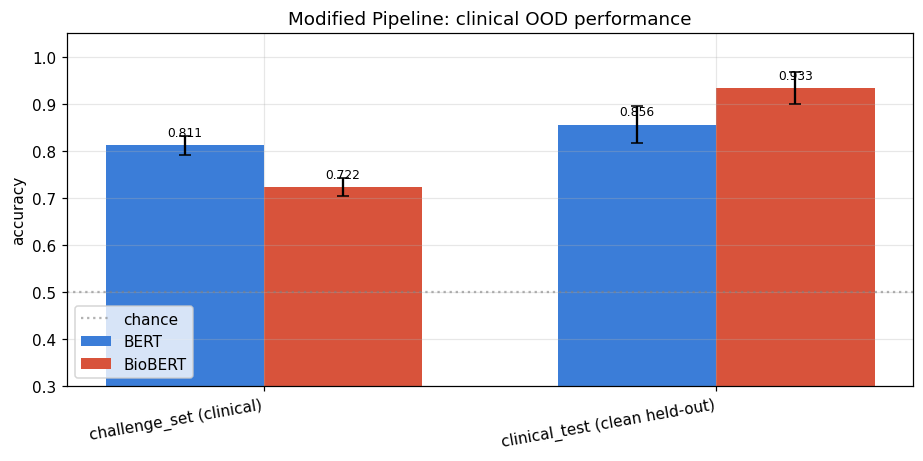

In [77]:
plot_acc_by_model(v3_summary,
                  "Modified Pipeline: clinical OOD performance",
                  color_map=MODEL_COLORS)

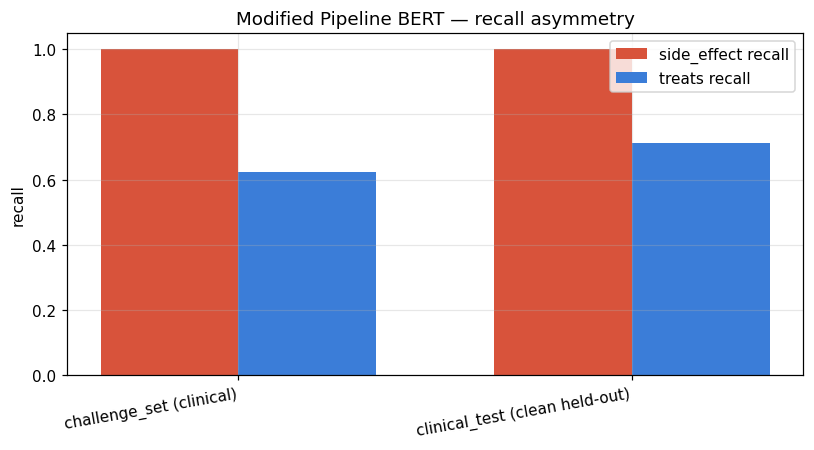

In [78]:
plot_recall_asymmetry(v3_df, "bert",
                      "Modified Pipeline BERT — recall asymmetry")

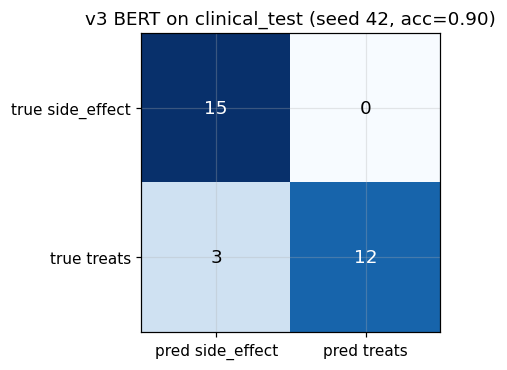

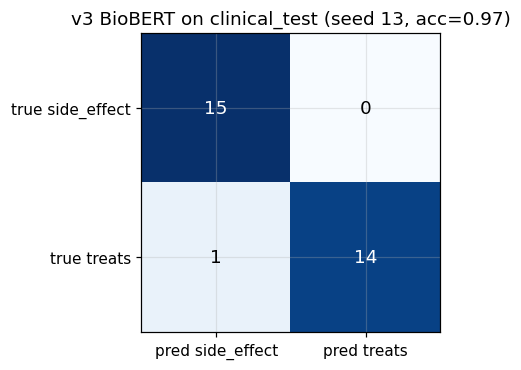

In [79]:
if not v3_df.empty:
    for model in MODELS:
        sub = v3_df[(v3_df["model"] == model) &
                    (v3_df["eval_set"] == "clinical_test (clean held-out)")]
        if sub.empty:
            continue
        best = sub.loc[sub["accuracy"].idxmax()]
        plot_confusion(
            best["confusion_matrix"],
            f"v3 {model.upper() if model == 'bert' else 'BioBERT'} on clinical_test "
            f"(seed {best['seed']}, acc={best['accuracy']:.2f})",
        )

---

## 4. Side-by-side comparison

In [80]:
comparison = pd.concat([
    baseline_df.assign(system="DrugBank-only baseline"),
    v3_df.assign(system="Modified Pipeline"),
], ignore_index=True)

pivot = (comparison
         .groupby(["system", "model", "eval_set"])["accuracy"]
         .agg(["mean", "std"])
         .round(4))
pivot

mean     std
system                 model   eval_set                                      
DrugBank-only baseline bert    challenge_set (clinical)        0.5222  0.0385
                               clinical_test (clean held-out)  0.5333  0.0333
                       biobert challenge_set (clinical)        0.6000  0.0667
                               clinical_test (clean held-out)  0.5778  0.1072
Modified Pipeline      bert    challenge_set (clinical)        0.8111  0.0192
                               clinical_test (clean held-out)  0.8556  0.0385
                       biobert challenge_set (clinical)        0.7222  0.0192
                               clinical_test (clean held-out)  0.9333  0.0333

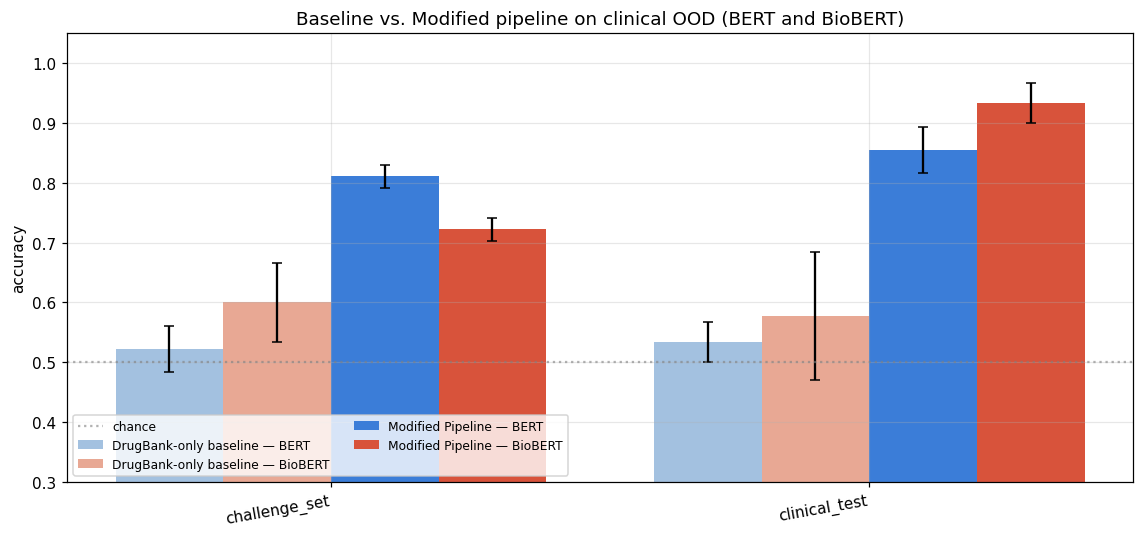

In [82]:
# Grouped bar chart: 4 bars per eval set (2 systems x 2 models).
if not comparison.empty:
    eval_order = [
        "challenge_set (clinical)",
        "clinical_test (clean held-out)",
    ]
    combos = [
        ("DrugBank-only baseline", "bert",    "#a3c1e0"),
        ("DrugBank-only baseline", "biobert", "#e8a894"),
        ("Modified Pipeline",     "bert",    "#3b7dd8"),
        ("Modified Pipeline",     "biobert", "#d8533b"),
    ]

    fig, ax = plt.subplots(figsize=(10.5, 5))
    x = np.arange(len(eval_order))
    width = 0.2
    positions = [-1.5, -0.5, 0.5, 1.5]

    for (system, model, color), pos in zip(combos, positions):
        sub = comparison[(comparison["system"] == system) &
                         (comparison["model"] == model)]
        if sub.empty:
            continue
        means = [sub[sub["eval_set"] == e]["accuracy"].mean() for e in eval_order]
        stds = [sub[sub["eval_set"] == e]["accuracy"].std() for e in eval_order]
        stds = [0 if np.isnan(s) else s for s in stds]
        model_display = "BERT" if model == "bert" else "BioBERT"
        ax.bar(x + pos * width, means, width, yerr=stds, capsize=3,
               label=f"{system} — {model_display}", color=color)

    ax.axhline(0.5, color="gray", linestyle=":", alpha=0.6, label="chance")
    ax.set_xticks(x)
    ax.set_xticklabels([e.split(" (")[0] for e in eval_order],
                       rotation=10, ha="right")
    ax.set_ylabel("accuracy")
    ax.set_ylim(0.3, 1.05)
    ax.set_title("Baseline vs. Modified pipeline on clinical OOD (BERT and BioBERT)")
    ax.legend(loc="lower left", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

---

## 6. Findings

**Lack of Datasets.** Lack of available datasets (for clinical tasks) led us to combine DrugBank and BC5CDR datasets but they have template-based (lack of diversity) sentences which led to high in-distribution accuracy in both the baseline and modified pipelines. Therefore, evaluation was done on AI-generated real world test cases.

**Cheap probes detect register shortcuts.** A bag-of-words logistic regression on the naive BC5CDR + DrugBank merge hits ~98% accuracy with source-fingerprint top features (refer to the output of the corresponding shell) — after DrugBank-only-baseline training. This led us to go ahead with LLM paraphrasing.

**LLM paraphrasing fixes register mismatch where regex substitution cannot.** The BC5CDR/DrugBank difference is grammatical (past-tense event vs present-tense stative), not lexical. Replacing individual phrases does not close the gap; rewriting whole sentences does.



## 7. Conclusion

Overall, the modified pipeline with BioBERT performed the best on the clinical test set. BioBERT’s strong performance likely stems from its pretraining on biomedical and clinical text. Therefore, we add this to our overall project pipeline.